<h1 align="center">GCMs CORRECTION NOTEBOOK</h1> 
<h1 align="center">Simple MQM</h1> 
<hr></hr>
<b>This Notebook is for correcting the GCMs outputs data before using it for <i>Elmer/Ice</i> simulations</b>.

Statistical correction method : 
- Monthly empirical CDF mapping for temperature
- Monthly empirical CDF mapping for precipitation
- Multiplicative factor of 1.301 on precipitation for accumulation

<b>Modification V. Peyaud 13/05/2026 for MPI SSP245</b>.
- New directories
- Change proplot to matplotib

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime

from scipy.stats import rv_histogram as pystat # method from Clauzel
from scipy.stats import rv_histogram # standard method
from scipy.stats import linregress

import warnings 
warnings.filterwarnings("ignore",category=FutureWarning)

#Define reference time for correction (same period as SAFRAN data)
ref_time=slice('1975','2014');
latARG=45.9833
lonARG= 6.9333

In [2]:
# Which Computer ?
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

dirinSAF = 'safran/'
dirouMQM = 'GCM_simpleMQM/' 

In [3]:
def get_slopes_and_pvalue(wp):

    wp_meanyear_hist = wp_meanyear[:86,:,:]

    
    origin_hist=np.full(wp.shape,np.nan)
    slope_hist=np.full(wp.shape,np.nan)
    pvalue_hist=np.full(wp.shape,np.nan)
    
   
    for i in range(wp_meanyear.shape[2]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanyear.shape[1]):
            #for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanyear_hist.shape[0]), wp_meanyear_hist[:,j,i])
                origin_hist[j][i] = linregress_hist.intercept
                slope_hist[j][i] = linregress_hist.slope
                pvalue_hist[j][i] = linregress_hist.pvalue
                

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [4]:
# Some lists
month=['January','February','March','April','May','June',
      'July','August','September','October','November','December']
                #                                   #
colorsMonth = [                                     #
    "#1f77b4",  # Bleu (Janvier - Hiver)            #
    "#aec7e8",  # Bleu clair (Février - Hiver)      #
    "#2ca02c",  # Vert (Mars - Printemps)           # 
    "#98df8a",  # Vert clair (Avril - Printemps     #
    "#ffbb78",  # Orange clair Mai - Printemps)     #    
    "#ff7f0e",  # Orange (Juin - Été)               # 
    "#d62728",  # Rouge (Juillet - Été)             # 
    "#ff9896",  # Rouge clair (Août - Été)          # 
    "#9467bd",  # Violet (Septembre - Automne)      #
    "#8c564b",  # Marron Octobre - Automne          #
    "#c49c94",   # Marron clair (Novembre - Automne) #
    "#c5b0d5"  # Violet clair (Décembre - Hiver)   #
]


# SAFRAN

## SAFRAN Clauzel et al. 2023

In [5]:
#Load SAFRAN reference temperature data
#temp_saf=xr.open_dataset('safran_daily_tas.nc')
datT_saf=xr.open_dataset(dirinSAF+'safran_daily_tas.nc')
temp_saf=datT_saf.tas.sel(Number_of_points=0)
temp_saf

<xarray.DataArray 'tas' (time: 14610)> Size: 58kB
[14610 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 117kB 1975-01-01 1975-01-02 ... 2014-12-31

In [6]:
#Load Historical CMIP model precerature data
#prec_saf=xr.open_dataset('safran_daily_pr.nc')
datP_saf=xr.open_dataset(dirinSAF+'safran_daily_pr.nc')
prec_saf=datP_saf.pr.sel(Number_of_points=0)
prec_saf

<xarray.DataArray 'pr' (time: 14610)> Size: 58kB
[14610 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 117kB 1975-01-01 1975-01-02 ... 2014-12-31

## SAFRAN from Gilbert (2026)

In [7]:
temp2 = np.loadtxt(dirinSAF+'SafranDailyTemp_1959_2023_MtBlanc.dat', delimiter=',', unpack=True)
prec2 = np.loadtxt(dirinSAF+'SafranDailyPrecip_1959_2023_MtBlanc.dat', delimiter=',', unpack=True)
len(temp2)

23954

In [8]:
# Convert dates
# 1. Date format
date_format = "%m/%d/%Y"
dateG = datetime.datetime.strptime('1/01/1959', date_format)
dateC = datetime.datetime.strptime('1/01/1975', date_format)

# 2. Nb of days between starting dates of Clauzel and 
delta = dateC - dateG
print("Nb of days between starting dates of Clauzel and GilbGilbert ert: ",delta.days) 
date2Index = np.arange(-delta.days, len(temp2)-delta.days, 1)#

# 3. Creer une plage de dates pour les donnees SAFRAN Gilbert  (1 date par jour)
dates2 = pd.date_range(start='1/01/1959', periods=len(temp2), freq="D")

# 4. Option : Creer un DataFrame pour associer les valeurs aux dates
calendar = pd.DataFrame({"Date": dates2, "Valeur": date2Index})

print("calendar:\n", calendar)

Nb of days between starting dates of Clauzel and GilbGilbert ert:  5844
calendar:
             Date  Valeur
0     1959-01-01   -5844
1     1959-01-02   -5843
2     1959-01-03   -5842
3     1959-01-04   -5841
4     1959-01-05   -5840
...          ...     ...
23949 2024-07-27   18105
23950 2024-07-28   18106
23951 2024-07-29   18107
23952 2024-07-30   18108
23953 2024-07-31   18109

[23954 rows x 2 columns]


In [9]:
# Conversion en DataArray avec des coordonnées temporelle
temp_saf2 = xr.DataArray( temp2, dims=["time"], coords={"time": dates2} )
prec_saf2 = xr.DataArray( prec2, dims=["time"], coords={"time": dates2} )

In [10]:
temp_saf[:] # Clauzel 2023

<xarray.DataArray 'tas' (time: 14610)> Size: 58kB
[14610 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 117kB 1975-01-01 1975-01-02 ... 2014-12-31

In [11]:
slope, intercept, r_value, p_value, std_err = linregress(np.arange(temp_saf.shape[0]), temp_saf[:])
print(slope, intercept, r_value, p_value, std_err)
#
slope_saf, intercept_saf, r_value_saf, p_value_saf, std_err_saf = slope, intercept, r_value, p_value, std_err

0.00013474627755945688 0.00813266156751935 0.08686755472669021 7.07467283512066e-26 1.2785537757830923e-05


In [12]:
temp_saf2[:] # Gilbert 2026

<xarray.DataArray (time: 23954)> Size: 192kB
array([ -3.2,  -5.4, -11.4, ...,  15.8,  16.3,  15. ], shape=(23954,))
Coordinates:
  * time     (time) datetime64[us] 192kB 1959-01-01 1959-01-02 ... 2024-07-31

In [13]:
slope, intercept, r_value, p_value, std_err = linregress(np.arange(temp_saf2.shape[0]), temp_saf2[:])
print(slope, intercept, r_value, p_value, std_err)
#
slope_saf2, intercept_saf2, r_value_saf2, p_value_saf2, std_err_saf2 = slope, intercept, r_value, p_value, std_err

0.00010330671911413089 -0.2313958621066079 0.10941760662262233 1.0644878053901993e-64 6.063942104335739e-06


Text(0, 0.5, 'Precip ($mm~d^{-1}$)')

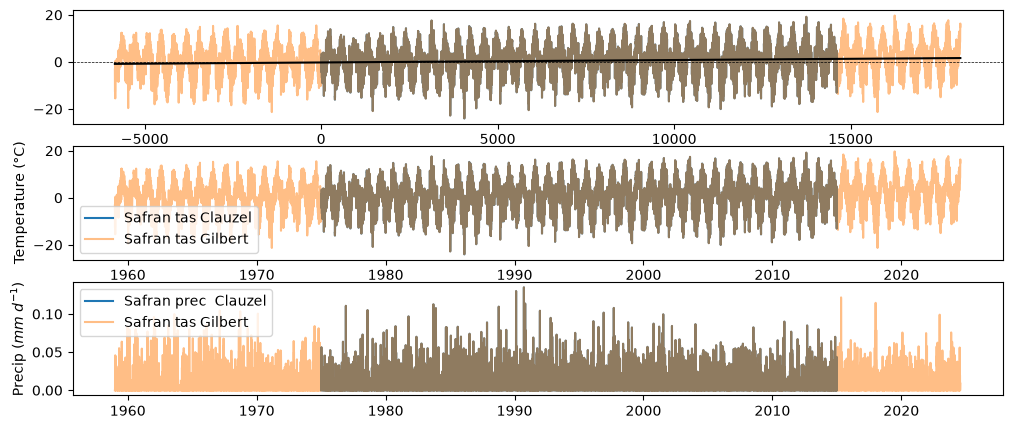

In [14]:
# Figure Temp SAFRAN
fig, axs = plt.subplots(3, 1, figsize=(12, 5))

ax = axs[0]
ax.plot(temp_saf.values, label='Safran tas Clauzel')
ax.plot(date2Index,temp_saf2,alpha=.5, label='Safran tas Gilbert')
#
ax.plot(date2Index, intercept + slope*date2Index, 'k', label='fitted line')
ax.axhline(y=0., color='k', linestyle='--',lw=0.5)
#ax.legend(loc='lower left')
ax = axs[1]
ax.plot(datT_saf.time,datT_saf.tas,label='Safran tas Clauzel')
ax.plot(dates2,temp_saf2,alpha=.5, label='Safran tas Gilbert')
ax.legend(loc='lower left')
ax.set_ylabel('Temperature (°C)')
ax = axs[2]
ax.plot(datP_saf.time,datP_saf.pr,label='Safran prec  Clauzel')
ax.plot(dates2,prec_saf2,alpha=.5, label='Safran tas Gilbert')
ax.legend(loc='upper left')
ax.set_ylabel('Precip ($mm~d^{-1}$)')

400
0
1
2
3
4
5
6
7
8
9
10
11


Text(0.5, 0.92, ' SAFRAN Gilbert 2026 histogram by month')

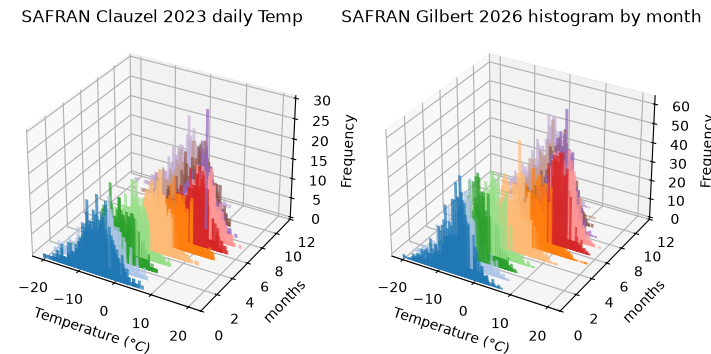

In [15]:
# Plot 3D Histograms by month SAFRAN
temp_lim=(-20,20)
bins_t=int(temp_lim[1]*2/0.1)
print(bins_t)

fig = plt.figure(figsize=(8.5, 4))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

m_array = np.linspace(0,11,11)

for m in range(12):#loop over month
    ##SAFRAN
    print(m)
    # Filter data for the specific month (m+1)
    monthly_saf1 = temp_saf.where(temp_saf.time.dt.month == m+1, drop=True)  
    monthly_saf2 = temp_saf2.where(temp_saf2.time.dt.month == m+1, drop=True)
    
    counts_s1, bins_s1 = np.histogram(monthly_saf1, bins=bins_t, range=temp_lim) ### retourne des 0
    counts_s2, bins_s2 = np.histogram(monthly_saf2, bins=bins_t, range=temp_lim)
    
    ax1.bar( bins_s1[2:-1], counts_s1[1:-1], zs=m, zdir='y', alpha=0.7,color=colorsMonth[m])
    ax2.bar( bins_s2[2:-1], counts_s2[1:-1], zs=m, zdir='y', alpha=0.7,color=colorsMonth[m])
#
ax1.set_xlabel('Temperature ($°C$)')
ax1.set_ylabel('months')
ax1.set_zlabel('Frequency')
#
ax2.set_xlabel('Temperature ($°C$)')
ax2.set_ylabel('months')
ax2.set_zlabel('Frequency')
#
ax1.set_ylim(0,12)
ax2.set_ylim(0,12)
#
ax1.set_title(f' SAFRAN Clauzel 2023 daily Temp')
ax2.set_title(f' SAFRAN Gilbert 2026 histogram by month')

# MPI-ESM1-2-HR_histo_ssp245

## MPI : correction calibration

**Temperature**

In [16]:
##Load hist-CMIP temperature
temp_ssp=xr.open_dataset(path_DIR+'/GCM/MPI-ESM1-2-HR/full_arg_tas_day_MPI-M_MPI-ESM1-2-HR_histo_ssp245_r1i1p1f1.nc').tas # new rep IPSL_CDQM_hist/ by Vince 
temp_ssp=temp_ssp[:,0,0] - 273.15 # From Kelvin to Celcius
temp_ssp                          # & keep just time dimension (remove lon,lat)

<xarray.DataArray 'tas' (time: 91676)> Size: 367kB
array([-1.9289551, -3.330536 , -6.6690063, ...,  1.5466003,  2.1961975,
       -1.7848206], shape=(91676,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 733kB 1850-01-01T12:00:00 ... 2100-12-31T1...
    lon      float64 8B 6.98
    lat      float64 8B 45.95
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: Treated scalar dime...
    institution:    MPIMET

In [17]:
#temp_ssp[:,0,0]
temp_ssp.shape[0]

91676

In [18]:
date2Index

array([-5844, -5843, -5842, ..., 18107, 18108, 18109], shape=(23954,))

In [19]:
# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(np.arange(temp_ssp.shape[0]), temp_ssp)
print(slope, intercept, r_value, p_value, std_err)
print(f'Trend is {slope*365.5*100.:.2f} °C/century') # From trend in day to trend in century
#
slope_ssp, intercept_ssp, r_value_ssp, p_value_ssp, std_err_saf = slope, intercept, r_value, p_value, std_err

3.332391793927887e-05 4.511808701052463 0.11992832061570823 8.864863991544752e-291 9.110985383764907e-07
Trend is 1.22 °C/century


Text(0, 0.5, 'Temperature ($°C$)')

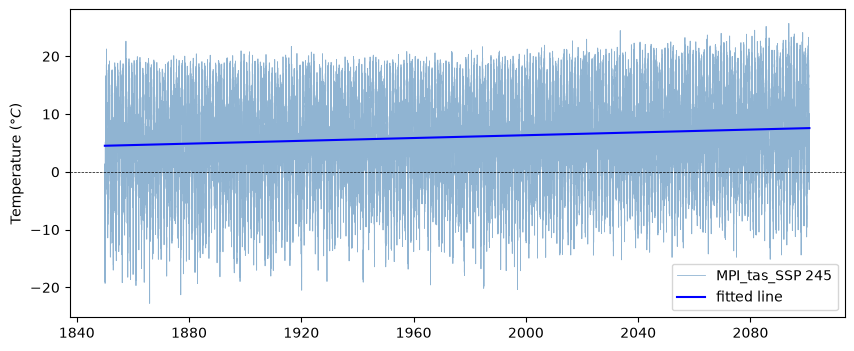

In [20]:
plt.figure(figsize=(10,4))
plt.plot(temp_ssp.time,temp_ssp, label='MPI_tas_SSP 245',color='steelblue',linestyle='-',alpha=.6,linewidth=0.6)
#
x_numeric = np.arange(len(temp_ssp))     # create numerical x axis
regression_line = intercept + slope * x_numeric # regression line over the x axis
plt.plot(temp_ssp.time, regression_line, 'blue', label='fitted line') # plot regression line over dates

plt.axhline(y=0., color='k', linestyle='--',lw=0.5)
plt.legend()
plt.ylabel('Temperature ($°C$)')

400


Text(0.5, 0.92, 'MPI daily tas histogram by month')

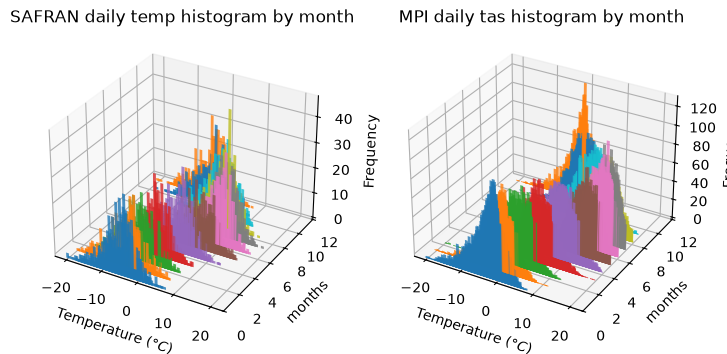

In [21]:
# Plot 3D Histograms by month SAFRAN and GCM
###Derive temperature monthly CDF###
temp_lim=(-20,20)
bins_t=int(temp_lim[1]*2/0.1)
print(bins_t)


fig = plt.figure(figsize=(8.5, 4))
axs = fig.add_subplot(121, projection='3d')
axd = fig.add_subplot(1, 2, 2, projection='3d')
for m in range(12):#loop over month
    ##SAFRAN Gilbert
    #print(m)
    # Filter data for the specific month (m+1)
    monthly_data = temp_ssp.where(temp_ssp.time.dt.month == m+1, drop=True) 
    monthly_safr = temp_saf2.where(temp_saf.time.dt.month == m+1, drop=True)      #SAFRAN Gilbert
    
    counts_d, bins_d = np.histogram(monthly_data, bins=bins_t, range=temp_lim) ### retourne des 0
    counts_s, bins_s = np.histogram(monthly_safr, bins=bins_t, range=temp_lim)
    
    axs.bar( bins_s[1:], counts_s, zs=m, zdir='y', alpha=0.8)
    axd.bar( bins_d[1:], counts_d, zs=m, zdir='y', alpha=0.8)
#
axs.set_xlabel('Temperature ($°C$)')
axs.set_ylabel('months')
axs.set_zlabel('Frequency')
#
axd.set_xlabel('Temperature ($°C$)')
axd.set_ylabel('months')
axd.set_zlabel('Frequency')
#
axs.set_ylim(0,12)
axd.set_ylim(0,12)
#
axs.set_title(f'SAFRAN daily temp histogram by month')
axd.set_title(f'MPI daily tas histogram by month')

0
<xarray.DataArray 'tas' (time: 7781)> Size: 31kB
array([-1.9289551, -3.330536 , -6.6690063, ...,  6.745636 ,  6.3070984,
        5.9040833], shape=(7781,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 62kB 1850-01-01T12:00:00 ... 2100-01-31T12...
    lon      float64 8B 6.98
    lat      float64 8B 45.95
    height   float64 8B 2.0
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: Treated scalar dime...
    institution:    MPIMET
1
<xarray.DataArray 'tas' (time: 7089)> Size: 28kB
array([ -7.607147 , -10.878845 , -15.96286  , ...,  -2.1664124,
        -0.8838806,   3.250824 ], shape=(7089,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 57kB 1850-02-01T12:00:00 ... 2100-02-28T12...
    l

Text(0, 0.5, 'Temperature ($°C$)')

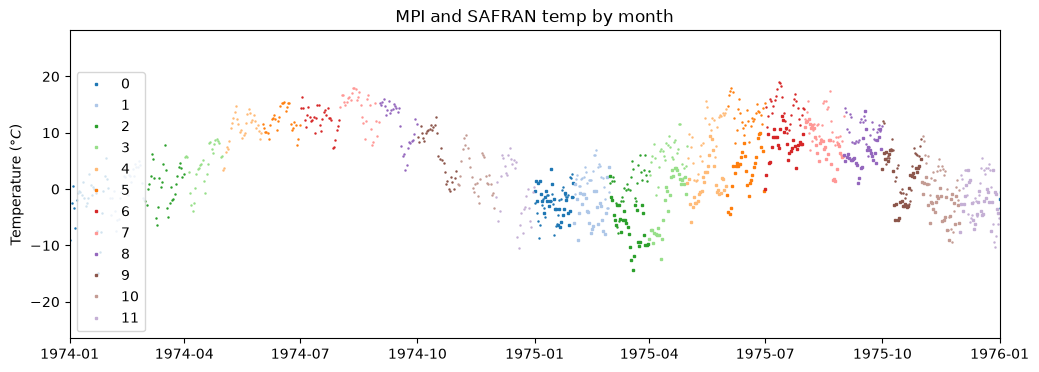

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))

for m in range(12):#loop over month
    ##SAFRAN
    print(m)
# Filter data for the specific month (m+1)
    monthly_data = temp_ssp.where(temp_ssp.time.dt.month == m+1, drop=True)  
    monthly_safr = temp_saf.where(temp_saf.time.dt.month == m+1, drop=True)

    print(monthly_data)
    ax.plot(monthly_data.time,monthly_data,'.',ms=1.5,color=colorsMonth[m],alpha=1)
    ax.plot(monthly_safr.time,monthly_safr,'s',ms=1.8,color=colorsMonth[m],label=m)
    
ax.legend(loc='lower left')
start_date = datetime.datetime(1830, 1, 1)
last_date = datetime.datetime(2103, 1, 1)
start_date = datetime.datetime(1974, 1, 1)
last_date = datetime.datetime(1976, 1, 1)
ax.set_xlim(start_date,last_date)
ax.set_title('MPI and SAFRAN temp by month')
ax.set_ylabel('Temperature ($°C$)')

**Precipitation**

In [23]:
##Load hist-CMIP precipitation
prec_ssp=xr.open_dataset(path_DIR+'/GCM/MPI-ESM1-2-HR/full_arg_pr_day_MPI-M_MPI-ESM1-2-HR_histo_ssp245_r1i1p1f1.nc').pr
prec_ssp = prec_ssp[:,0,0]*86.4 #3600*24/1000 # From m/s (kg m-2 s-1) to mm/d
prec_ssp                        # & keep just time dimension (remove lon,lat)

<xarray.DataArray 'pr' (time: 91676)> Size: 367kB
array([2.8936678e-04, 6.6996220e-04, 5.0944707e-04, ..., 1.1627376e-05,
       3.6216511e-03, 9.6216686e-03], shape=(91676,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 733kB 1850-01-01T12:00:00 ... 2100-12-31T1...
    lon      float64 8B 6.98
    lat      float64 8B 45.95
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    comment:        includes both liquid and solid phases
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: replaced missing va...
    institution:    MPIMET

Text(0, 0.5, 'Precipitation ($mm~d^{-1}$)')

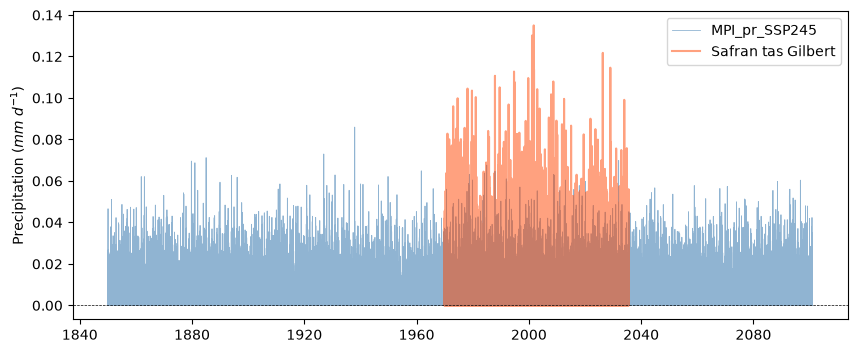

In [24]:
plt.figure(figsize=(10,4))
plt.plot(prec_ssp.time,prec_ssp, label='MPI_pr_SSP245',color='steelblue',linestyle='-',alpha=.6,linewidth=0.6)
#
x_numeric = np.arange(len(prec_ssp))     # create numerical x axis
regression_line = intercept + slope * x_numeric # regression line over the x axis
#plt.plot(prec_ssp.time, regression_line, 'blue', label='fitted line') # plot regression line over dates

plt.plot(prec_saf2,color='orangered',alpha=.5, label='Safran tas Gilbert')

plt.axhline(y=0., color='k', linestyle='--',lw=0.5)
plt.legend()
plt.ylabel('Precipitation ($mm~d^{-1}$)')

In [25]:
prec_lim=(0,.2)
bins_p=int(prec_lim[1]/0.002)
print(bins_p)

100


0
1
2
3
4
5
6
7
8
9
10
11


Text(0.5, 0.92, 'MPI Hist & SSP daily precip')

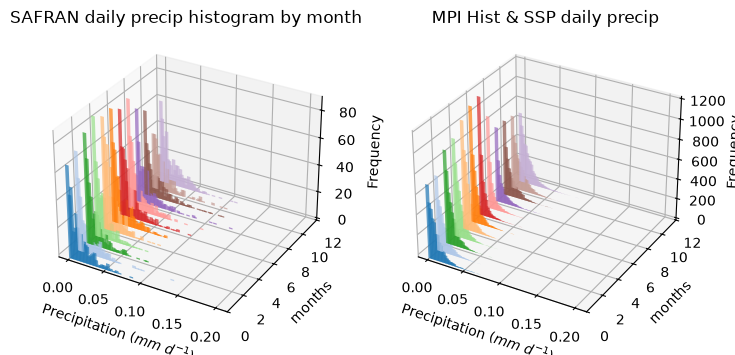

In [26]:
fig = plt.figure(figsize=(8.5, 4))
axs = fig.add_subplot(121, projection='3d')
axd = fig.add_subplot(1, 2, 2, projection='3d')
# First subplot


for m in range(12):#loop over month
    ##SAFRAN
    print(m)
    # Filter data for the specific month (m+1)
    monthly_data = prec_ssp.where(prec_ssp.time.dt.month == m+1, drop=True)  
    monthly_safr = prec_saf.where(prec_saf.time.dt.month == m+1, drop=True)
    
    counts_dp, bins_dp = np.histogram(monthly_data, bins=bins_p, range=prec_lim) ### retourne des 0
    counts_sp, bins_sp = np.histogram(monthly_safr, bins=bins_p, range=prec_lim)
    
    axs.bar( bins_sp[2:-1], counts_sp[1:-1], zs=m, zdir='y', alpha=0.7,color=colorsMonth[m],width=.005)
    axd.bar( bins_dp[2:-1], counts_dp[1:-1], zs=m, zdir='y', alpha=0.7,color=colorsMonth[m],width=.005)
#
axs.set_xlabel('Precipitation ($mm~d^{-1}$)')
axs.set_ylabel('months')
axs.set_zlabel('Frequency')
#
axd.set_xlabel('Precipitation ($mm~d^{-1}$)')
axd.set_ylabel('months')
axd.set_zlabel('Frequency')
#
axs.set_ylim(0,12)
axd.set_ylim(0,12)
#
axs.set_title(f'SAFRAN daily precip histogram by month')
axd.set_title(f'MPI Hist & SSP daily precip')

1
2
3
4
5
6
7
8
9
10
11
12


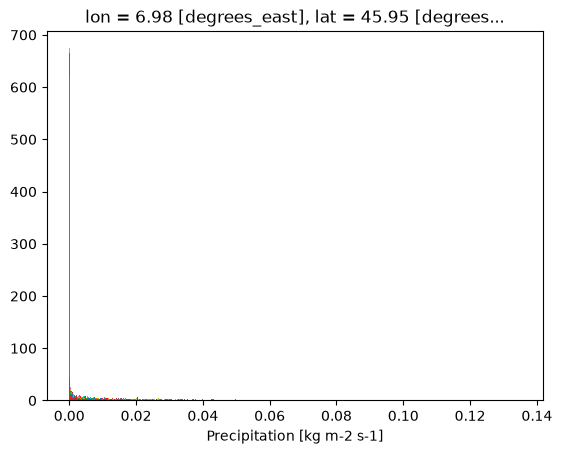

In [27]:
###Derive CDF### Cumulative distribution function # (From Clauzel Zenodo)
bins=1000
#initialize array : first dimension is temperature groups, second dimension is months
# may added ,density=True 
prec_ssp_dist=[]
prec_saf_dist=[]
for m in range(12):#loop over month
    print(m+1)
    ##SAFRAN
    dist=pystat(prec_saf.where(prec_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2],density=True) 
    prec_saf_dist+=[dist]
    ##Hist-CMIP
    dist=pystat(prec_ssp.sel(time=ref_time).where(prec_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2])
    prec_ssp_dist+=[dist]

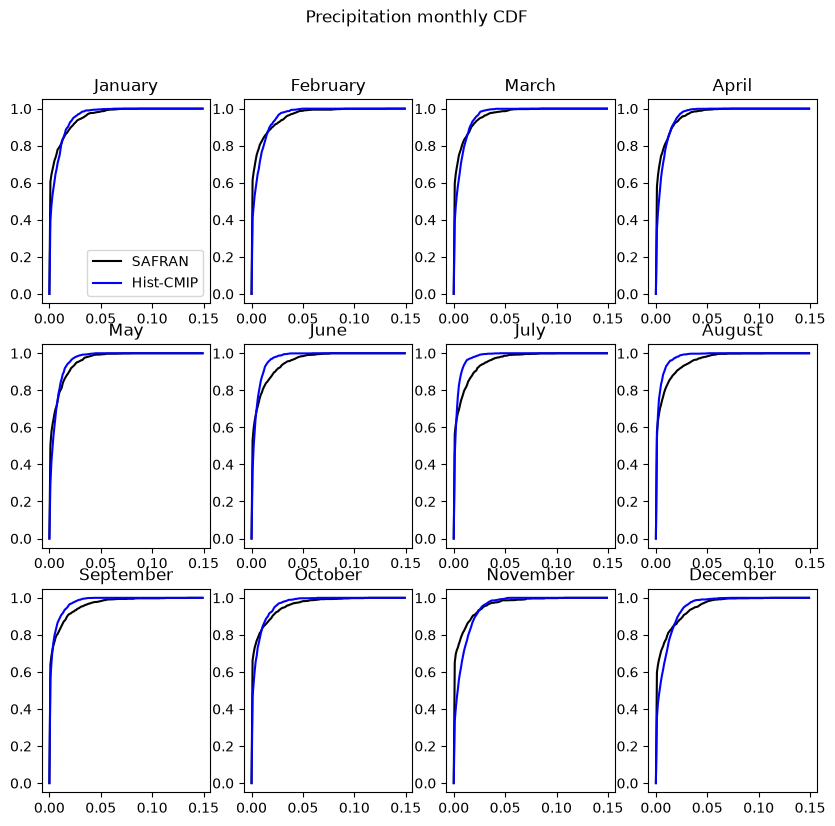

In [28]:
###Plot CDF### Cumulative distribution function
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(10,9));
fig.suptitle('Precipitation monthly CDF')
val_prec=np.arange(0,0.15,0.001)
for m in range(12):
    ax=axs.flatten()[m]
    ax.set_title(month[m])
    ax.plot(val_prec,prec_saf_dist[m].cdf(val_prec),c='black',label='SAFRAN');
    ax.plot(val_prec,prec_ssp_dist[m].cdf(val_prec),c='b',label='Hist-CMIP');
axs[0,0].legend();

## Correction GCM HIST+SSP

**Temperature**

In [29]:
# Datasets are:  temp_ssp & prec_ssp

0


/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:7: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:10: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:7: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])


1


/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:10: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:7: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])


2


...

/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:10: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])


10


/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:7: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:10: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])


11


/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:7: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/783656660.py:10: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])


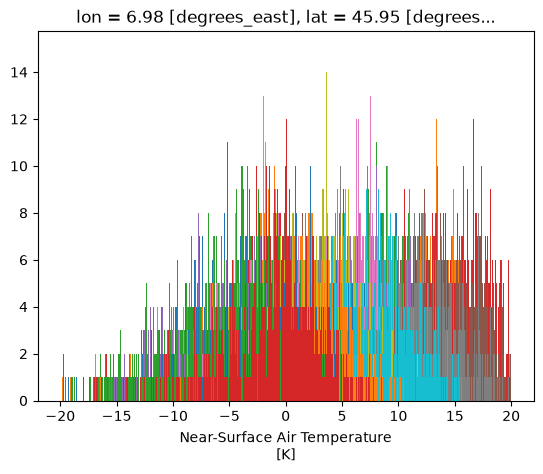

In [30]:
#initialize array : 
temp_saf_dist=[]
temp_ssp_dist=[]
for m in range(12):#loop over month
    ##SAFRAN
    print(m)
    dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
    temp_saf_dist+=[dist]
    ##Hist-ssp GCM
    dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
    temp_ssp_dist+=[dist]

In [31]:
#temp_ssp_cor

In [32]:
###Correction###
temp_ssp_cor=temp_ssp.copy()

#for r in range(temp_ssp_cor.shape[0][0]) :#loop over realization
if (True): # just to keep initial indentation
    for d in range(temp_ssp_cor.shape[0]):#loop over the days
        m=temp_ssp_cor[d].time.dt.month.values #month
        t=temp_ssp_cor[d].values #temperature
        temp_ssp_cor[d]=temp_saf_dist[m-1].ppf(temp_ssp_dist[m-1].cdf(t)) #correction
    #print(r+1)
temp_ssp_cor

<xarray.DataArray 'tas' (time: 91676)> Size: 367kB
array([-4.8582234 , -6.2680407 , -8.713576  , ..., -0.95739985,
       -0.23173717, -5.1347003 ], shape=(91676,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 733kB 1850-01-01T12:00:00 ... 2100-12-31T1...
    lon      float64 8B 6.98
    lat      float64 8B 45.95
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: Treated scalar dime...
    institution:    MPIMET

In [33]:
temp_ssp_cor.mean()

<xarray.DataArray 'tas' ()> Size: 4B
array(1.3120606, dtype=float32)
Coordinates:
    lon      float64 8B 6.98
    lat      float64 8B 45.95
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: Treated scalar dime...
    institution:    MPIMET

In [34]:
##Save to netCDF file
temp_ssp_cor.to_netcdf(dirouMQM+'temp_ssp_cor_simpleMQM.nc')

In [35]:
temp_ssp_cor.values

array([-4.8582234 , -6.2680407 , -8.713576  , ..., -0.95739985,
       -0.23173717, -5.1347003 ], shape=(91676,), dtype=float32)

In [36]:
##Save to .dat file for each member (1820-1849)
#for i in temp_piControl_cor.realization.values :
if (True): # just to keep initial indentation
    data=temp_ssp_cor.values
    np.savetxt(dirouMQM+'temp_ssp_cor_simpleMQM.dat',data,fmt='%.2f')

**Precipitation**

In [37]:
###Correction###
prec_ssp_cor=prec_ssp.copy()
#for r in range(prec_ssp_cor.shape[0]) :#loop over realization
if (True): # just to keep initial indentation
    for d in range(prec_ssp_cor.shape[0]):#loop over the days
        p=prec_ssp_cor[d].values #daily precipitation
        m=prec_ssp_cor[d].time.dt.month.values #month
        prec_ssp_cor[d]=prec_saf_dist[m-1].ppf(prec_ssp_dist[m-1].cdf(p)) #corrected precipitation
#    print(r+1)
accu_ssp_cor=1.301*prec_ssp_cor ##apply correctio factor for accumulation

IOStream.flush timed out


In [62]:
###Precipitation###
##Save to netCDF file
prec_ssp_cor.to_netcdf(dirouMQM+'prec_ssp_cor_simpleMQM.nc')
##Save to .dat file for each member (1820-1849)
#for i in prec_piControl_cor.realization.values :
if (True): # just to keep initial indentation
    data=prec_ssp_cor.values
    np.savetxt(dirouMQM+'prec_ssp_cor_simpleMQM.dat',data,fmt='%.3f')

###  ACCU ???????
### ###Accumulation###
### ##Save to netCDF file
### accu_piControl_cor.to_netcdf('IPSL/piControl/IPSL_accu_piControl_cor.nc')
### ##Save to .dat file for each member (1820-1849)
### for i in accu_piControl_cor.realization.values :
###     arr=accu_piControl_cor.sel(realization=i)
###     np.savetxt('IPSL/piControl/IPSL_accu_piControl_cor_real%d.dat'%(i+1),arr,fmt='%.3f')

**Plot**

Text(0, 0.5, 'Precipitation ($mm~d^{-1}$)')

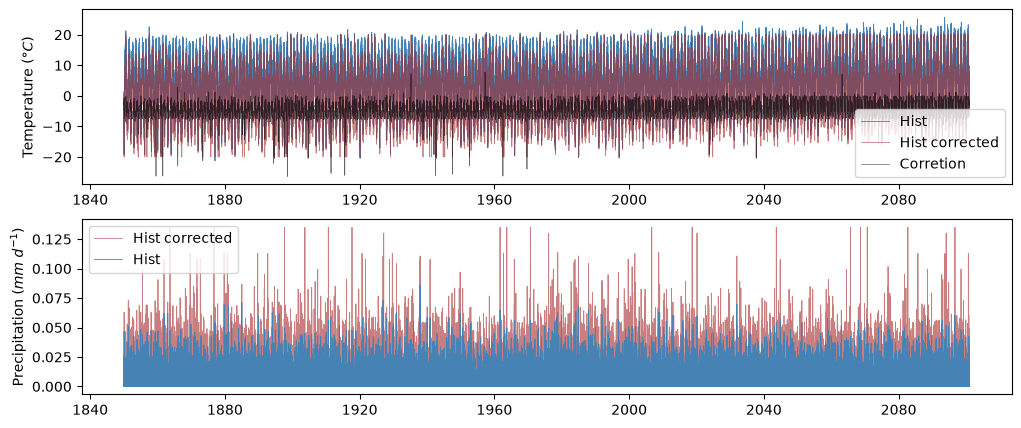

In [39]:
# Plot corrections.
fig, axs = plt.subplots(2, 1, figsize=(12, 5))

ax = axs[0]
ax.plot(temp_ssp.time,temp_ssp,linestyle='-',color='steelblue',linewidth=0.6,label='Hist')
ax.plot(temp_ssp.time,temp_ssp_cor,linestyle='-',color='brown',alpha=.6,linewidth=0.6,label='Hist corrected')
ax.plot(temp_ssp.time,temp_ssp_cor-temp_ssp,linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Corretion')
ax.legend()
ax.set_ylabel('Temperature ($°C$)')

ax = axs[1]

ax.plot(prec_ssp.time,prec_ssp_cor,linestyle='-',color='brown',alpha=.6,linewidth=0.6,label='Hist corrected')
ax.plot(prec_ssp.time,prec_ssp,linestyle='-',color='steelblue',linewidth=0.6,label='Hist')
#ax.plot(prec_ssp.time,prec_ssp_cor[:,0,0]-prec_ssp[:,0,0],linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Corretion')

ax.legend()
ax.set_ylabel('Precipitation ($mm~d^{-1}$)')

# IPSL (IPSL-CM6A-LR)

## IPSL : correction calibration

**Temperature**

In [40]:
##Load hist-CMIP temperature
temp_hist=xr.open_dataset('IPSL_CDQM_hist/IPSL_tas_hist_daily.nc').tas # new rep IPSL_CDQM_hist/ by Vince 
temp_hist[0]

<xarray.DataArray 'tas' (time: 60265)> Size: 241kB
[60265 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 482kB 1850-01-01T12:00:00 ... 2014-12-31T1...
    lat      float32 4B ...
    lon      float32 4B ...
    height   float64 8B ...

In [41]:
temp_hist[0].shape[0]

60265

In [42]:
# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(np.arange(temp_hist[0].shape[0]), temp_hist[0])
print(slope, intercept, r_value, p_value, std_err)
print(f'Trend is {slope*365.5*100.:.2f} °C/century') # From trend in day to trend in century
#
slope_hist, intercept_hist, r_value_hist, p_value_hist, std_err_hist = slope, intercept, r_value, p_value, std_err

2.7613053530429782e-05 2.79726921518432 0.05959529905361024 1.499473989872279e-48 1.8841022344178476e-06
Trend is 1.01 °C/century


Text(0.5, 0, 'Temperature (°C)')

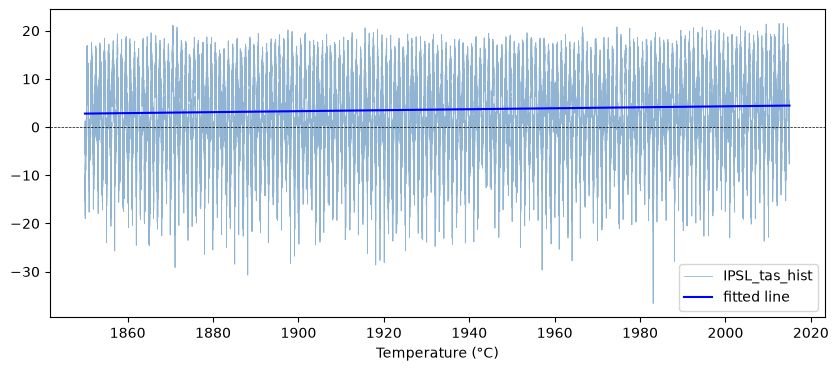

In [43]:
plt.figure(figsize=(10,4))
plt.plot(temp_hist[0].time,temp_hist[0], label='IPSL_tas_hist',color='steelblue',linestyle='-',alpha=.6,linewidth=0.6)

#
x_numeric = np.arange(len(temp_hist[0]))     # create numerical x axis
regression_line = intercept + slope * x_numeric # regression line over the x axis
plt.plot(temp_hist.time, regression_line, 'blue', label='fitted line') # plot regression line over dates

plt.axhline(y=0., color='k', linestyle='--',lw=0.5)
plt.legend()
plt.xlabel('Temperature (°C)')

In [44]:
# my histogram
temp_lim=(-20,20)
bins=int(temp_lim[1]*2/0.1)
bins

400

0


/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/1387370231.py:7: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])


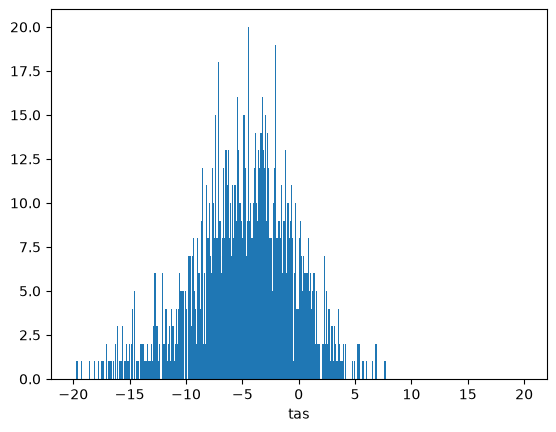

In [45]:
#initialize array : 
temp_hist_dist=[]
temp_saf_dist=[]
for m in range(1):#loop over month
    ##SAFRAN
    print(m)
    dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2])
    temp_saf_dist+=[dist]


0 January
1 February
2 March
3 April
4 May
5 June
6 July
7 August
8 September
9 October
10 November
11 December


Text(0.5, 0.92, 'IPSL Hist daily tas histogram by month')

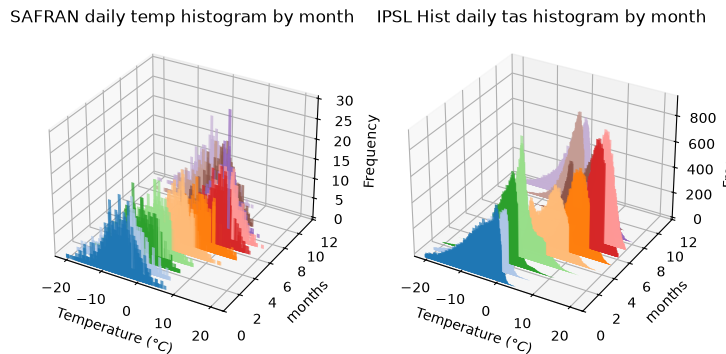

In [46]:
fig = plt.figure(figsize=(8.5, 4))
axs = fig.add_subplot(121, projection='3d')
axd = fig.add_subplot(1, 2, 2, projection='3d')
# First subplot


for m in range(12):#loop over month
    ##SAFRAN
    print(m,month[m])
    # Filter data for the specific month (m+1)
    monthly_data = temp_hist.where(temp_hist.time.dt.month == m+1, drop=True)  
    monthly_safr = temp_saf.where(temp_saf.time.dt.month == m+1, drop=True)
    
    counts_d, bins_d = np.histogram(monthly_data, bins=bins, range=temp_lim)
    counts_s, bins_s = np.histogram(monthly_safr, bins=bins, range=temp_lim)
    
    axs.bar( bins_s[1:], counts_s, zs=m, zdir='y', alpha=0.7,color=colorsMonth[m])
    axd.bar( bins_d[1:], counts_d, zs=m, zdir='y', alpha=0.7,color=colorsMonth[m])
#
axs.set_xlabel('Temperature ($°C$)')
axs.set_ylabel('months')
axs.set_zlabel('Frequency')
#
axd.set_xlabel('Temperature ($°C$)')
axd.set_ylabel('months')
axd.set_zlabel('Frequency')
#
axs.set_ylim(0,12)
axd.set_ylim(0,12)
#
axs.set_title(f'SAFRAN daily temp histogram by month')
axd.set_title(f'IPSL Hist daily tas histogram by month')

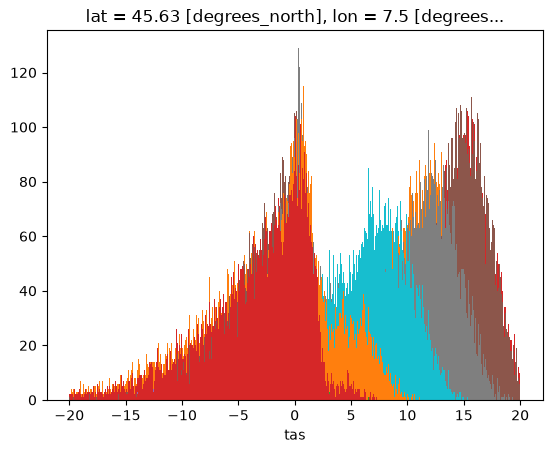

In [47]:
###Derive temperature monthly CDF### # (From Clauzel Zenodo)
temp_lim=(-40,40);bins=int(temp_lim[1]*2/0.01) # initial value from Clauzel
temp_lim=(-20,20);bins=int(temp_lim[1]*2/0.05)
# added ,density=True
#initialize array : 
temp_hist_dist=[]
temp_saf_dist=[]
for m in range(12):#loop over month
    ##SAFRAN
    dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2],density=True)
    temp_saf_dist+=[dist]
    ##Hist-CMIP
    dist=pystat(temp_hist.sel(time=ref_time).where(temp_hist.time.dt.month==m+1,drop=True).plot.hist(bins=bins,range=temp_lim)[0:2],density=True)
    temp_hist_dist+=[dist]

In [48]:
#temp_saf_dist : distribution of Temp for Safran (rv_histogram) 
temp_saf_dist[0]
print(temp_saf_dist[0].a,temp_saf_dist[0].b,temp_saf_dist[0].xtol, temp_saf_dist[0].badvalue)
print(temp_saf_dist[0].name,temp_saf_dist[0].shapes)#,temp_saf_dist[0].seed)

-20.0 20.0 1e-14 nan
Distribution None


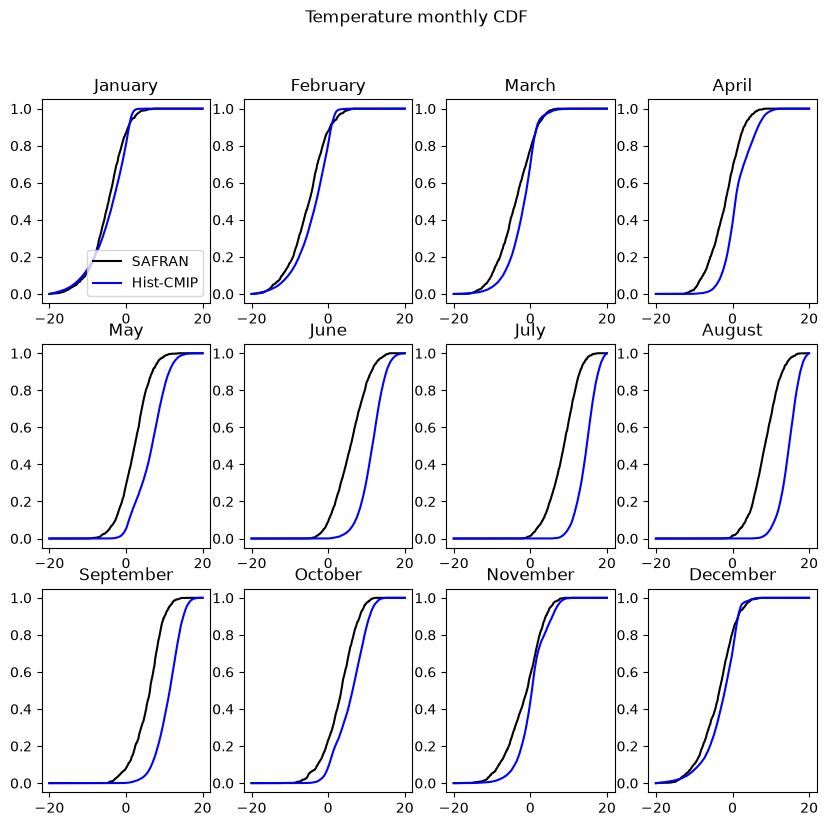

In [49]:
###Plot CDF### (Cumulative distribution function)
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(10,9));
fig.suptitle('Temperature monthly CDF')
val_temp=np.arange(-20,20,0.01)
for m in range(12):
    ax=axs.flatten()[m]
    ax.set_title(month[m]) # month list defined above
    ax.plot(val_temp,temp_saf_dist[m].cdf(val_temp),c='black',label='SAFRAN');
    ax.plot(val_temp,temp_hist_dist[m].cdf(val_temp),c='blue',label='Hist-CMIP');
axs[0,0].legend();

**Precipitation**

In [50]:
##Load hist-CMIP precipitation
prec_hist=xr.open_dataset('IPSL_CDQM_hist/IPSL_pr_hist_daily.nc').pr
prec_hist

<xarray.DataArray 'pr' (realization: 10, time: 60265)> Size: 2MB
[602650 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 482kB 1850-01-01T12:00:00 ... 2014-12-31T1...
    lat      float32 4B ...
    lon      float32 4B ...
Dimensions without coordinates: realization
Attributes:
    long_name:           Precipitation
    units:               m/d
    online_operation:    average
    cell_methods:        area: time: mean
    interval_operation:  900 s
    interval_write:      1 d
    standard_name:       precipitation_flux
    description:         at surface; includes both liquid and solid phases fr...
    history:             none
    cell_measures:       area: areacella

In [51]:
prec_lim=(0,.2)
bins_p=int(prec_lim[1]/0.005)
print(bins_p)

#bins_p=1000

40


0
1
2
3
4
5
6
7
8
9
10
11


Text(0.5, 0.92, 'IPSL Hist daily precip histogram by month')

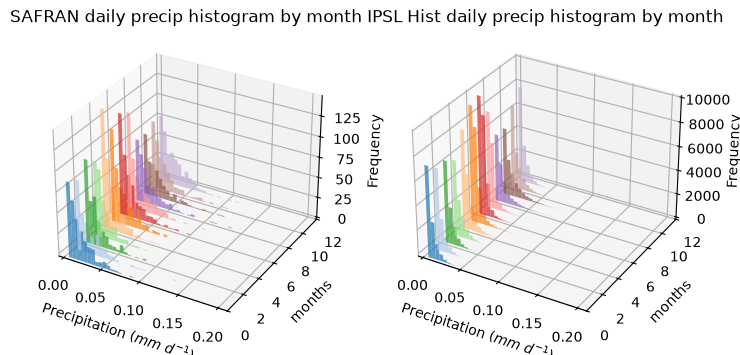

In [52]:
fig = plt.figure(figsize=(8.5, 4))
axs = fig.add_subplot(121, projection='3d')
axd = fig.add_subplot(1, 2, 2, projection='3d')
# First subplot


for m in range(12):#loop over month
    ##SAFRAN
    print(m)
    # Filter data for the specific month (m+1)
    monthly_data = prec_hist.where(prec_hist.time.dt.month == m+1, drop=True)  
    monthly_safr = prec_saf.where(prec_saf.time.dt.month == m+1, drop=True)
    
    counts_dp, bins_dp = np.histogram(monthly_data, bins=bins_p, range=prec_lim) ### retourne des 0
    counts_sp, bins_sp = np.histogram(monthly_safr, bins=bins_p, range=prec_lim)
    
    axs.bar( bins_sp[2:-1], counts_sp[1:-1], zs=m, zdir='y', alpha=0.7,color=colorsMonth[m],width=.005)
    axd.bar( bins_dp[2:-1], counts_dp[1:-1], zs=m, zdir='y', alpha=0.7,color=colorsMonth[m],width=.005)
#
axs.set_xlabel('Precipitation ($mm~d^{-1}$)')
axs.set_ylabel('months')
axs.set_zlabel('Frequency')
#
axd.set_xlabel('Precipitation ($mm~d^{-1}$)')
axd.set_ylabel('months')
axd.set_zlabel('Frequency')
#
axs.set_ylim(0,12)
axd.set_ylim(0,12)
#
axs.set_title(f'SAFRAN daily precip histogram by month')
axd.set_title(f'IPSL Hist daily precip histogram by month')

/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/1842563137.py:9: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(prec_saf.where(prec_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2]) # ,density=True
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_12928/1842563137.py:9: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  dist=pystat(prec_saf.where(prec_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2]) # ,density=True


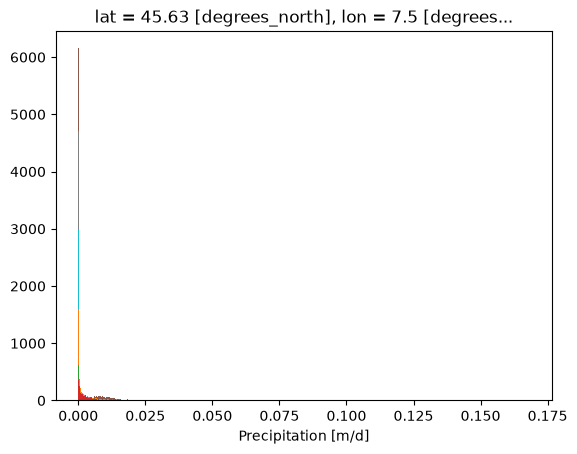

In [53]:
###Derive CDF### Cumulative distribution function # (From Clauzel Zenodo)
bins=1000
#initialize array : first dimension is temperature groups, second dimension is months
# may added ,density=True 
prec_hist_dist=[]
prec_saf_dist=[]
for m in range(12):#loop over month
    ##SAFRAN
    dist=pystat(prec_saf.where(prec_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2]) # ,density=True 
    prec_saf_dist+=[dist]
    ##Hist-CMIP
    dist=pystat(prec_hist.sel(time=ref_time).where(prec_hist.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2])
    prec_hist_dist+=[dist]

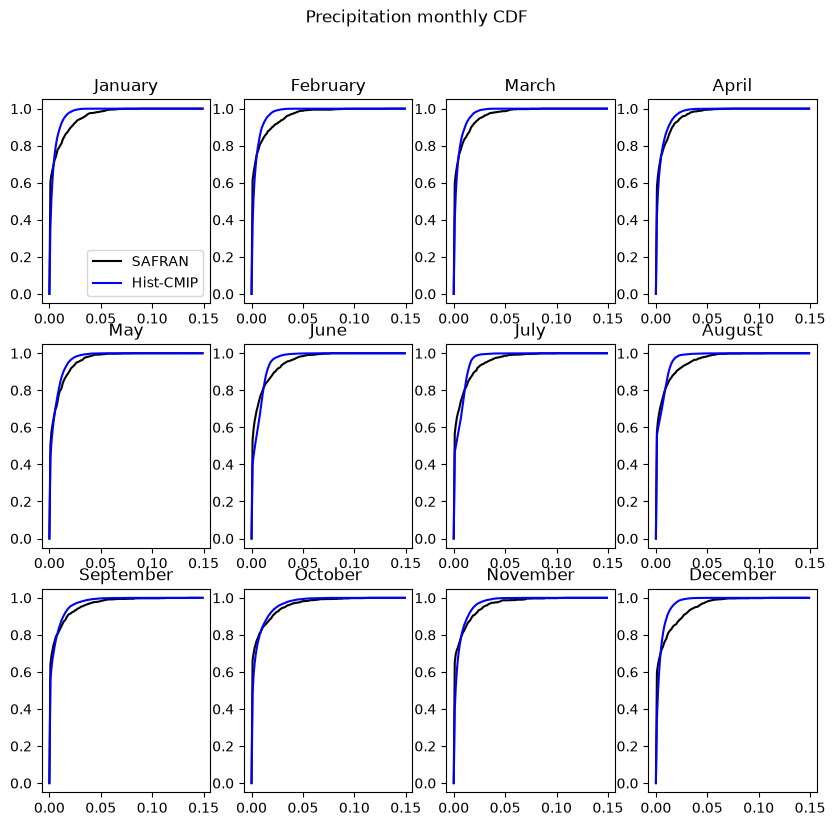

In [54]:
###Plot CDF### Cumulative distribution function
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(10,9));
fig.suptitle('Precipitation monthly CDF')
val_prec=np.arange(0,0.15,0.001)
for m in range(12):
    ax=axs.flatten()[m]
    ax.set_title(month[m])
    ax.plot(val_prec,prec_saf_dist[m].cdf(val_prec),c='black',label='SAFRAN');
    ax.plot(val_prec,prec_hist_dist[m].cdf(val_prec),c='b',label='Hist-CMIP');
axs[0,0].legend();

**Accumulation**

Accumulation = precipitation * 1.301

In [55]:
aaa = 1.

## Correction IPSL : hist-CMIP (Clauzel 2023)

**Temperature**

In [56]:
##Correction is :
#temp_hist_cor[r,d]=temp_saf_dist[m-1].ppf(temp_hist_dist[m-1].cdf(t)) 
#temp_hist_cor (realisation & day) equal
#temp_saf_dist[m-1].ppf : Obs Percent point function (inverse of cdf) 
#    of temp_hist_dist[m-1].cdf(t) : model Cumulative distribution function

In [57]:
###Correction###
temp_hist_cor=temp_hist.copy()
#for r in range(temp_hist_cor.shape[0]) :#loop over realization
for r in range(2) :#SHORTEN THE LOOP
    for d in range(temp_hist_cor.shape[1]):#loop over the days
        m=temp_hist_cor[r,d].time.dt.month.values #month
        t=temp_hist_cor[r,d].values #temperature
        temp_hist_cor[r,d]=temp_saf_dist[m-1].ppf(temp_hist_dist[m-1].cdf(t)) #correction
    print(r+1)
temp_hist_cor

1
2


<xarray.DataArray 'tas' (realization: 10, time: 60265)> Size: 2MB
[602650 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 482kB 1850-01-01T12:00:00 ... 2014-12-31T1...
    lat      float32 4B ...
    lon      float32 4B ...
    height   float64 8B ...
Dimensions without coordinates: realization

In [58]:
##Save to netCDF file
temp_hist_cor.to_netcdf(dirouMQM+'IPSL_temp_hist_cor.nc')

In [59]:
##Save to .dat file for each member (1850-2014)
for i in temp_hist_cor.realization.values :
    arr=temp_hist_cor.sel(realization=i)
    np.savetxt(dirouMQM+'IPSL_temp_hist_cor_real%d.dat'%(i+1),arr,fmt='%.2f')

**Precipitation**

In [60]:
###Correction###
prec_hist_cor=prec_hist.copy()
accu_hist_cor=prec_hist.copy()
#for r in range(prec_hist_cor.shape[0]) :#loop over realization
for r in range(2) :#SHORTEN THE LOOP
    for d in range(prec_hist_cor.shape[1]):#loop over the days
        p=prec_hist_cor[r,d].values #daily precipitation
        m=prec_hist_cor[r,d].time.dt.month.values #month
        prec_hist_cor[r,d]=prec_saf_dist[m-1].ppf(prec_hist_dist[m-1].cdf(p)) #corrected precipitation
    print(r+1)
accu_hist_cor=1.301*prec_hist_cor

1
2


In [61]:
###Precipitation###
##Save to netCDF file
prec_hist_cor.to_netcdf(dirouMQM+'IPSL_prec_hist_cor.nc')    
##Save to .dat file for each member (1850-2014)
for i in prec_hist_cor.realization.values :
    arr=prec_hist_cor.sel(realization=i)
    np.savetxt(dirouMQM+'IPSL_prec_hist_cor_real%d.dat'%(i+1),arr,fmt='%.3f')
    
###Accumulation###
##Save to netCDF file
accu_hist_cor.to_netcdf(dirouMQM+'IPSL_accu_hist_cor.nc')    
##Save to .dat file for each member (1850-2014)
for i in accu_hist_cor.realization.values :
    arr=accu_hist_cor.sel(realization=i)
    np.savetxt(dirouMQM+'IPSL_accu_hist_cor_real%d.dat'%(i+1),arr,fmt='%.3f')

SyntaxError: unterminated string literal (detected at line 11) (3207972900.py, line 11)

**Plot**

In [ ]:
# Plot corrections.
fig, axs = plt.subplots(2, 1, figsize=(12, 5))

ax = axs[0]
ax.plot(temp_hist.time,temp_hist[0],linestyle='-',color='steelblue',linewidth=0.6,label='Hist')
ax.plot(temp_hist.time,temp_hist_cor[0],linestyle='-',color='brown',alpha=.6,linewidth=0.6,label='Hist corrected')
ax.plot(temp_hist.time,temp_hist_cor[0]-temp_hist[0],linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Corretion')
ax.legend()
ax.set_ylabel('Temperature ($°C$)')

ax = axs[1]
ax.plot(prec_hist.time,prec_hist_cor[0],linestyle='-',color='brown',linewidth=0.6,label='Hist corrected')
ax.plot(prec_hist.time,prec_hist[0],linestyle='-',color='steelblue',linewidth=0.6,label='Hist')

#ax.plot(prec_hist.time,prec_hist_cor[0]-prec_hist[0],linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Corretion')

ax.legend()
ax.set_ylabel('Precipitation ($mm~d^{-1}$)')

## GCM

**Temperature**

...

**Precipitation**

...

# Next GCM ... (to be followed)

Figures

In [ ]:
#Define reference time for correction (same period as SAFRAN data)
ref_time=slice('1975','2014')
##Derive temperature trend
#temp_saf
ref=temp_saf.sel(time=ref_time).mean()
temp_saf_trend=(temp_saf.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist
#ref=temp_hist.sel(time=ref_time).mean()
#temp_hist_trend=(temp_hist.groupby('time.year').mean('time').mean('realization')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_cor
#ref=temp_hist_cor.sel(time=ref_time).mean()
#temp_hist_cor_trend=(temp_hist_cor.groupby('time.year').mean('time').mean('realization')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp
ref=temp_ssp.sel(time=ref_time).mean()
temp_ssp_trend=(temp_ssp.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp_cor
ref=temp_ssp_cor.sel(time=ref_time).mean()
temp_ssp_cor_trend=(temp_ssp_cor.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_histalp
#ref=temp_histalp.sel(time=ref_time).mean()
#temp_histalp_trend=(temp_histalp.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

In [ ]:
prec_ssp_cor

In [ ]:
##Derive temperature/precipitation distribution
delta_t=1
range_temp=np.arange(-30,30+delta_t,delta_t)

dist_prec_saf=np.zeros((len(range_temp)-1,))
#dist_prec_hist=np.zeros((len(temp_hist.realization),len(range_temp)-1))
#dist_prec_cor=np.zeros((len(temp_hist_cor.realization),len(range_temp)-1))

dist_prec_ssp=np.zeros((len(range_temp)-1))
dist_prec_corS=np.zeros((len(range_temp)-1))
#dist_prec_simpleMQM=np.zeros((len(temp_hist_MQM.realization),len(range_temp)-1))

for i in range(dist_prec_ssp.shape[0]):
    dist_prec_saf[i]=prec_saf.where(temp_saf>range_temp[i],drop=True).where(temp_saf<=range_temp[i+1],drop=True).sum()/prec_saf.sum()
    ###dist_prec_cor[:,i]=prec_hist_cor.sel(time=ref_time).where((temp_hist_cor>range_temp[i])&(temp_hist_cor<=range_temp[i+1])).sum('time')/prec_hist_cor.sel(time=ref_time).sum('time')   
    ###dist_prec_hist[:,i]=prec_hist.sel(time=ref_time).where((temp_hist>range_temp[i])&(temp_hist<=range_temp[i+1])).sum('time')/prec_hist.sel(time=ref_time).sum('time')   
    dist_prec_corS[i]=prec_ssp_cor.sel(time=ref_time).where((temp_ssp_cor>range_temp[i])&(temp_ssp_cor<=range_temp[i+1])).sum('time')/prec_ssp_cor.sel(time=ref_time).sum('time')    
    #dist_prec_corS[:]=prec_ssp_cor[:,0,0].sel(time=ref_time).where((temp_ssp_cor[:,0,0]>range_temp[i])&(temp_ssp_cor[:,0,0]<=range_temp[i+1])).sum('time')/prec_ssp_cor.sel(time=ref_time).sum('time')   
    #dist_prec_ssp[i]=prec_ssp[:,0,0].sel(time=ref_time).where((temp_ssp[:,0,0]>range_temp[i])&(temp_ssp[:,0,0]<=range_temp[i+1])).sum('time')/prec_ssp.sel(time=ref_time).sum('time')  
    dist_prec_ssp[i]=prec_ssp.sel(time=ref_time).where((temp_ssp>range_temp[i])&(temp_ssp<=range_temp[i+1])).sum('time')/prec_ssp.sel(time=ref_time).sum('time')  
    #dist_prec_simpleMQM[:,i]=prec_hist_MQM.sel(time=ref_time).where((temp_hist_MQM>range_temp[i])&(temp_hist_MQM<=range_temp[i+1])).sum('time')/prec_hist_MQM.sel(time=ref_time).sum('time')   

In [ ]:
#temp_hist_cor_trend

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#####################################
#A
#temp_hist_trend.plot(ax=ax[0],color='steelblue',
#                         label='historical  ($\Delta=%.2f°C$)'%(temp_hist_trend.sel(year=1850).values))
#temp_hist_cor_trend.plot(ax=ax[2,0],color='vibrant green',
#                         label='CDQM     ($\Delta=%.2f°C$)'%(temp_hist_cor_trend.sel(year=1850).values))
#temp_hist_MQM_trend.plot(ax=ax[2,0],color='red',
#temp_hist_cor_trend.plot(ax=ax[0],color='red',
#                         label='SQM        ($\Delta=%.2f°C$)'%(temp_hist_cor_trend.sel(year=1850).values))
#temp_histalp_trend.plot(ax=ax[0],linestyle=':',color='dark brown',
#                         label='HISTALP ($\Delta=%.2f°C$)'%(temp_histalp_trend.sel(year=1850).values))

temp_ssp_trend.plot(ax=ax[0],color='blue',
                         label='hist+ssp  ($\Delta=%.2f°C$)'%(temp_ssp_trend.sel(year=1850).values))
#temp_hist_cor_trend.plot(ax=ax[2,0],color='vibrant green',
#                         label='CDQM     ($\Delta=%.2f°C$)'%(temp_hist_cor_trend.sel(year=1850).values))
#temp_hist_MQM_trend.plot(ax=ax[2,0],color='red',
temp_ssp_cor_trend.plot(ax=ax[0],color='orangered',
                         label='SQM hist+ssp ($\Delta=%.2f°C$)'%(temp_ssp_cor_trend.sel(year=1850).values))

temp_saf_trend.plot(ax=ax[0],linestyle='--',color='black',
                         label='SAFRAN')
ax[0].legend(framealpha=1)
ax[0].set_xlim(1850,2100)
ax[0].set_ylim(-1.5,1.8)
ax[0].set_xlabel('year')
ax[0].set_ylabel('$\Delta T [°C]$')
ax[0].text(2005,-1.4,s='b',fontweight='bold',fontsize=13)

######################################
#B
#ax[0,1].fill_between(range_temp[:-1]+(delta_t/2),np.percentile(dist_prec_hist.cumsum(axis=1),0,axis=0),np.percentile(dist_prec_hist.cumsum(axis=1),100,axis=0),alpha=0.3,label=None,color='steelblue')
#ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_hist.mean(axis=0).cumsum(),label='historical',color='steelblue',linewidth=2)

#ax[0,1].fill_between(range_temp[:-1]+(delta_t/2),np.percentile(dist_prec_cor.cumsum(axis=1),0,axis=0),np.percentile(dist_prec_cor.cumsum(axis=1),100,axis=0),alpha=0.3,label=None,color='vibrant green')
########ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_cor.mean(axis=0).cumsum(),label='CDQM',color='vibrant green',linewidth=2)

#ax[0,1].fill_between(range_temp[:-1]+(delta_t/2),np.percentile(dist_prec_simpleMQM.cumsum(axis=1),0,axis=0),np.percentile(dist_prec_simpleMQM.cumsum(axis=1),100,axis=0),alpha=0.3,label=None,color='red')
#ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_cor.mean(axis=0).cumsum(),label='SQM hist',color='red',linewidth=2)

ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_ssp.cumsum(),label='hist+ssp',color='blue',linewidth=2)
ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_corS.cumsum(),label='SQM ssp',color='orangered',linewidth=2)


ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_saf.cumsum(),alpha=1,label='SAFRAN',color='black',linestyle='--')

ax[1].legend(framealpha=1,loc='upper left')
#ax[1].set_xlim(-15,18)
#ax[1].set_ylim(0,1)
ax[1].set_xlabel('$T\ [°C]$')
ax[1].set_ylabel('P [%]')
ax[1].text(16,0.035,s='c',fontweight='bold',fontsize=13)
